In [2]:
#Importing the required libraries
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm

In [3]:
#parameters
S0 = 100  # initial stock price
K = 100   # strike price
T = 1     # time to maturity in years
r = 0.03  # risk-free interest rate
sigma = 0.2  # volatility

d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

V_BS = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2) 

print("The Black-Scholes price of the call option is:", round(V_BS, 3))

The Black-Scholes price of the call option is: 9.413


Number of simulations: 100, Monte Carlo price: 10.289, 95% CI: [7.428, 13.15]
Number of simulations: 500, Monte Carlo price: 8.496, 95% CI: [7.335, 9.657]
Number of simulations: 1000, Monte Carlo price: 9.139, 95% CI: [8.279, 9.998]
Number of simulations: 5000, Monte Carlo price: 9.194, 95% CI: [8.807, 9.581]
Number of simulations: 10000, Monte Carlo price: 9.302, 95% CI: [9.026, 9.579]
Number of simulations: 50000, Monte Carlo price: 9.326, 95% CI: [9.203, 9.448]
Number of simulations: 100000, Monte Carlo price: 9.541, 95% CI: [9.453, 9.629]
Number of simulations: 500000, Monte Carlo price: 9.431, 95% CI: [9.392, 9.47]


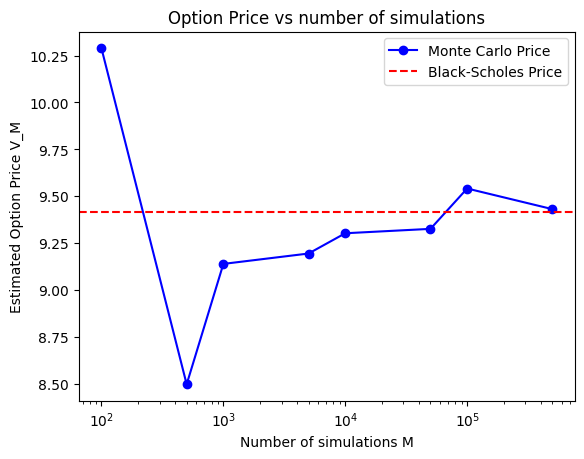

In [4]:
#Monte Carlo simulation for option pricing
M_values = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5]  # number of simulations
m = len(M_values)

V_M = np.zeros(m)
SE_M = np.zeros(m)
CI = np.zeros(m)
np.random.seed(0)  # for reproducibility

for i in range(m):
    Zm = np.random.standard_normal(int(M_values[i]))
    ST_m = S0 * np.exp((r - 0.5 * sigma **2)*T+sigma * np.sqrt(T) * Zm) 
    h = np.maximum(ST_m - K, 0)
    V_M[i] = np.exp(-r*T) * 1/len(ST_m) * np.sum(h)
    SE_M[i] = np.exp(-r*T) * np.std(h) / np.sqrt(len(ST_m))
    CI[i] = 1.96 * SE_M[i]
    print(f"Number of simulations: {int(M_values[i])}, Monte Carlo price: {round(V_M[i], 3)}, 95% CI: [{round(V_M[i] - CI[i], 3)}, {round(V_M[i] + CI[i], 3)}]")

plt.plot(M_values, V_M, 'o-',label='Monte Carlo Price', color='blue')
plt.xscale('log')
plt.xlabel('Number of simulations M')
plt.ylabel('Estimated Option Price V_M')
plt.title('Option Price vs number of simulations')
plt.axhline(y=V_BS, color='r', linestyle='--', label='Black-Scholes Price')
plt.legend()
plt.show()

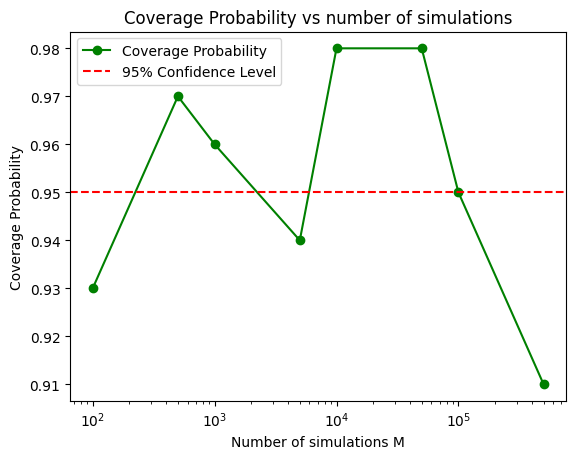

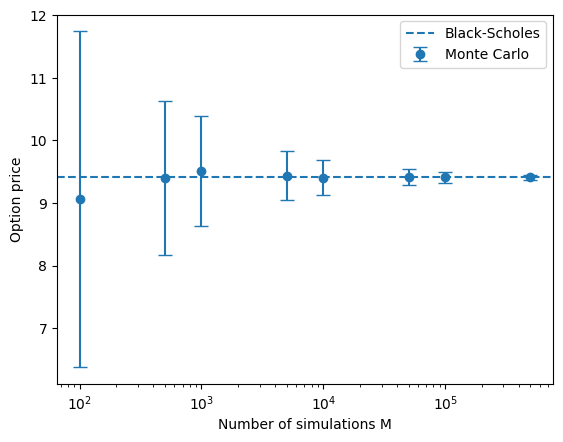

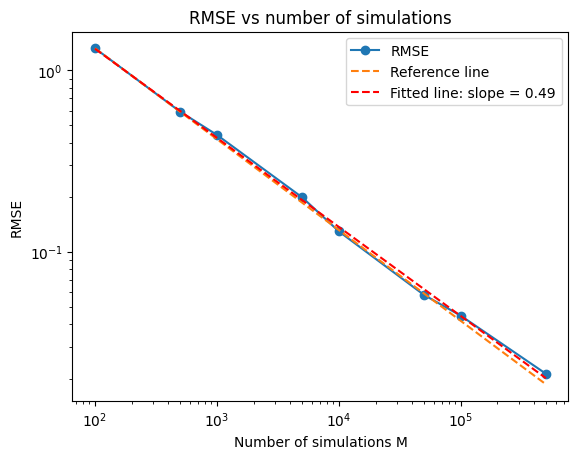

In [5]:
#convergence analysis
R = 100  # number of repetitions for each M

V_Mj = np.zeros((m,R))
SE_Mj = np.zeros((m,R))
CIj = np.zeros((m,R))
RMSE = np.zeros(m)
coverage = np.zeros(m)
np.random.seed(0)  # for reproducibility

for i in range(m):

    for j in range(R): # 100 repetitions for each M
        Zm = np.random.standard_normal(int(M_values[i]))
        ST_m = S0 * np.exp((r - 0.5 * sigma **2)*T+sigma * np.sqrt(T) * Zm) 
        h = np.maximum(ST_m - K, 0)
        V_Mj[i, j] = np.exp(-r*T) * 1/len(ST_m) * np.sum(h)
        SE_Mj[i, j] = np.exp(-r*T) * np.std(h) / np.sqrt(len(ST_m))
        CIj[i, j] = 1.96 * SE_Mj[i, j]
    lower = V_Mj[i, :] - CIj[i, :]
    upper = V_Mj[i, :] + CIj[i, :]
    coverage[i] = np.mean((lower <= V_BS) & (V_BS <= upper))

    RMSE[i] = np.sqrt(1/R * np.sum((V_Mj[i, :] - V_BS)**2))


plt.plot(M_values, coverage, 'o-', label='Coverage Probability', color='green')
plt.xscale('log')
plt.xlabel('Number of simulations M')
plt.ylabel('Coverage Probability')
plt.title('Coverage Probability vs number of simulations')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Confidence Level')
plt.legend()
plt.show()

mean_estimates = np.mean(V_Mj, axis=1)
mean_CI = np.mean(CIj, axis=1)

plt.errorbar(M_values, mean_estimates, label = 'Monte Carlo', yerr=mean_CI,fmt='o',capsize=5)
plt.axhline(V_BS, linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.xlabel('Number of simulations M')
plt.ylabel('Option price')
plt.legend()
plt.show()

b = 0.5
C = RMSE[0] * M_values[0]**b
refline = C * np.array(M_values)**(-b)
slope, intercept = np.polyfit(np.log(M_values), np.log(RMSE), 1)
beta = -slope

plt.loglog(M_values, RMSE, 'o-', label='RMSE')
plt.loglog(M_values, refline, '--', label='Reference line')
plt.loglog(M_values, np.exp(slope * np.log(M_values) + intercept), 'r--', label=f'Fitted line: slope = {beta:.2f}')
plt.xlabel('Number of simulations M')
plt.ylabel('RMSE')
plt.title('RMSE vs number of simulations')
plt.legend()
plt.show()

Variance Reduction Factor (VRF) for each M value [2.6157873  2.48815173 1.83796057 1.88940151 1.09330391 2.10255944
 1.5779738  2.22899727]


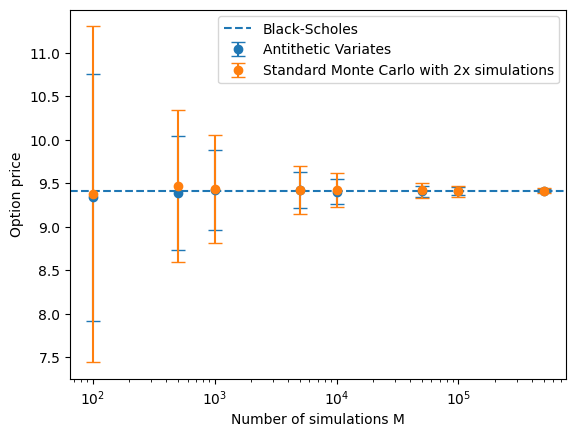

In [8]:
#Monte Carlo simulation for option pricing

M_values = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5]  # number of simulations G;r om g;r r'tt! 
m = len(M_values)
R = 100  # number of repetitions for each M

V_2M = np.zeros((m, R))
V_M_AV = np.zeros((m, R))
SE_2M = np.zeros((m,R))
SE_M_AV = np.zeros((m,R))
CI_2Mj = np.zeros((m,R))
CI_M_AVj = np.zeros((m,R))
VRF = np.zeros(m)
np.random.seed(0)  

for i in range(m):

    for j in range(R): # 100 repetitions for each M
        Zm = np.random.standard_normal(int(M_values[i]))
        Z2m = np.random.standard_normal(int(2*M_values[i]))
        ST_2m = S0 * np.exp((r - 0.5 * sigma **2)*T+sigma * np.sqrt(T) * Z2m) 
        ST_m_p = S0 * np.exp((r - 0.5 * sigma **2)*T+sigma * np.sqrt(T) * Zm) 
        ST_m_m = S0 * np.exp((r - 0.5 * sigma **2)*T-sigma * np.sqrt(T) * Zm) 
        h_2m = np.maximum(ST_2m - K, 0)
        Y_m = 1/2 * (np.maximum(ST_m_p - K, 0) + np.maximum(ST_m_m - K, 0))
        V_M_AV[i, j] = np.exp(-r*T) * 1/len(Y_m) * np.sum(Y_m)
        SE_M_AV[i, j] = np.exp(-r*T) * np.std(Y_m) / np.sqrt(len(Y_m))
        CI_M_AVj[i, j] = 1.96 * SE_M_AV[i, j]
        V_2M[i, j] = np.exp(-r*T) * 1/len(h_2m) * np.sum(h_2m)
        SE_2M[i, j] = np.exp(-r*T) * np.std(h_2m) / np.sqrt(len(h_2m))
        CI_2Mj[i, j] = 1.96 * SE_2M[i, j]

    VRF[i] = (np.var(V_2M[i, :])/np.var(V_M_AV[i, :]))

print("Variance Reduction Factor (VRF) for each M value", VRF)

# Implementera detta neråt! 
mean_estimates_AV = np.mean(V_M_AV, axis=1)
mean_CI_AV = np.mean(CI_M_AVj, axis=1)

mean_estimates_2M = np.mean(V_2M, axis=1)
mean_CI_2M = np.mean(CI_2Mj, axis=1)

plt.errorbar(M_values, mean_estimates_AV, label = 'Antithetic Variates', yerr=mean_CI_AV,fmt='o',capsize=5)
plt.errorbar(M_values, mean_estimates_2M, label = 'Standard Monte Carlo with 2x simulations', yerr=mean_CI_2M,fmt='o',capsize=5)        
plt.axhline(V_BS, linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.xlabel('Number of simulations M')
plt.ylabel('Option price')
plt.legend()
plt.show()
#slut på implementation 

